# FX Pairs: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error
in it is silent where it is made and reaches every metric and every backtest after it.
This notebook fixes the execution convention, proves each labelled row has a complete
forward window inside one pair, measures how much independent information those rows
carry, establishes the floor a feature has to clear, and writes the files stage 03 reads.

## Learning objectives

- Put a bar series on the session clock the decision cadence is defined in, before any
  forward window is measured
- Assert, rather than describe, that every labelled window is complete and gap-free inside
  one pair
- Seal a diagnostic on the label's endpoint rather than on its observation date
- Price the overlap in a multi-session label, both as decay and as an effective row count
- Establish the floor a feature has to clear, under a standard error that prices in that
  overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads four-hour spot bars through `load_fx_pairs()`, whose
coverage [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the universe, the label set, the horizons and the
holdout boundary. Writes `labels/fwd_ret_1d.parquet`, `labels/fwd_ret_5d.parquet` and
`labels/fwd_ret_21d.parquet`, each with a `.digest.json` sidecar beside it.
`03_financial_features.py` reads `fwd_ret_1d.parquet`, which it names directly rather
than resolving `labels.primary`, so changing that key here does not move stage 03.

In [1]:
"""FX Pairs: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_fx_pairs
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "fx_pairs"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Both parameters are unset by default, and both are read below. `START_DATE` trims the
history to a later start; `MAX_SYMBOLS` keeps only the first pairs in alphabetical order.
Either one shortens a run at the cost of a thinner panel: the rank correlation in Section G
and the cross-sectional dispersion in Section E both need a wide cross-section on each
session to mean anything.

In [2]:
MAX_SYMBOLS = None
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and
all three are declared in trading sessions.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in LABEL_NAMES
}
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
LONGEST_LABEL = max(HORIZONS, key=HORIZONS.get)
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
HOLDOUT_END = date.fromisoformat(setup["evaluation"]["holdout_end"])
CALENDAR = "CME_FX"  # the venue calendar that implements the NY 5pm rollover

print(f"Labels: {LABEL_NAMES}, primary {PRIMARY_LABEL}, horizons {HORIZONS} sessions")
print(f"Holdout opens {HOLDOUT_START}, and seals the label endpoint")

Labels: ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_21d'], primary fwd_ret_1d, horizons {'fwd_ret_1d': 1, 'fwd_ret_5d': 5, 'fwd_ret_21d': 21} sessions
Holdout opens 2024-01-01, and seals the label endpoint


## A. The learning task

The hypothesis is cross-sectional reversal. Among a fixed universe of twenty liquid crosses,
the claim is that the pairs that have appreciated most over the past two quarters
subsequently underperform the pairs that have not - a macro-driven mean reversion in
relative value, ranked across the universe rather than judged pair by pair. The label is
therefore a forward spot return on the pair itself, and the strategy that consumes it is
long-short across the twenty.

The decision cadence comes from `setup.yaml`: the New York 5pm close is observed and the
resulting position is entered at the next bar's open, which fixes the primary horizon at
one session. The two variants ask whether the same relationship pays over a week and over
a month. Those are questions about how fast the reversal unwinds and about how often the
book has to turn over, rather than second hypotheses, so Section G measures the floor
against the primary label, and `05_evaluation` measures decay across the three.

## B. Preparation before the label

Spot FX has no exchange close, so a daily bar is a convention rather than an observation.
The provider delivers four-hour bars stamped in UTC; the decision cadence is defined at the
New York 5pm rollover, and for eight hours out of every twenty-four the two clocks put a
bar on different calendar days. `TradingCalendar("CME_FX")` assigns each
four-hour bar to the session it actually traded in, and the daily close is the last bar of
that session rather than the last bar before midnight UTC. Aggregating on the UTC date
instead puts a Sunday-evening bar and the Monday session in the same row.

The aggregation sorts within each session group before taking its last bar, because a
Polars `group_by` does not contractually preserve input order, and a daily close taken
from an arbitrary bar of the session is wrong without ever raising.

No eligibility filter runs before the shift, and that ordering matters: once rows are
dropped from inside a series, a shift counts survivors, the horizon stops being measured in
sessions, and the window silently spans whatever was removed. The universe is the fixed
twenty-pair list `setup.yaml` declares, which carries the selection bias
`01_feasibility_analysis` documents.

In [4]:
def to_daily_sessions(bars: pl.DataFrame) -> pl.DataFrame:
    """Aggregate four-hour bars to one row per pair and venue session."""
    sessions = TradingCalendar(CALENDAR).get_sessions(pd.DatetimeIndex(bars["timestamp"]))
    return (
        bars.rename({"timestamp": "bar_ts"})
        .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
        .drop_nulls("timestamp")
        .group_by(["symbol", "timestamp"])
        .agg(pl.col("close").sort_by("bar_ts").last())
        .sort(["symbol", "timestamp"])
    )


bars = load_fx_pairs(frequency="4h", start_date=START_DATE, end_date=str(HOLDOUT_END))
prices = to_daily_sessions(bars.select(["symbol", "timestamp", "close"]))
if MAX_SYMBOLS is not None:
    keep = sorted(prices["symbol"].unique().to_list())[:MAX_SYMBOLS]
    prices = prices.filter(pl.col("symbol").is_in(keep))

assert prices.filter(pl.col("timestamp").dt.weekday() > 5).height == 0, "weekend session"

# Digest of the data the labels are built from, recorded as every label's `inputs`: a
# re-run against a refreshed download is otherwise indistinguishable from this one.
MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "close"])

print(f"{prices['symbol'].n_unique()} pairs, {prices.height:,} pair-sessions")
print(f"Sessions {prices['timestamp'].min()} to {prices['timestamp'].max()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

20 pairs, 77,480 pair-sessions
Sessions 2011-01-03 to 2025-12-31
market_data digest: ee846141912988f9


## C. Label construction

One execution convention, written once and applied at all three horizons:

$$r^{(h)}_{i,t} = \frac{P_{i,t+h}}{P_{i,t}} - 1$$

where $P$ is pair $i$'s New York 5pm close and $t+h$ counts $h$ **venue sessions** for that
pair: Chapter 7.2's close-to-close convention. It is not the convention the backtest fills
at - `setup.yaml` places execution at the next bar's open - and that difference is a real
gap, left to `15_costs`, which sweeps commission and spread rather than the return
definition.

Two bookkeeping columns are numbered here, on the complete session series, because both
mean something only before a row is dropped: `from_end` counts back from each pair's last
session for Section D's boundary profile, and `session` numbers its sessions forward so
Section F's overlap statistics keep counting sessions once the null tail and the holdout
are filtered out. Neither reaches a label parquet, which selects three columns.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close return over `horizon` venue sessions, per pair."""
    return df.with_columns(
        (pl.col("close").shift(-horizon).over("symbol") / pl.col("close") - 1).alias(name)
    )


labels_df = prices.with_columns(
    (pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")).alias("from_end"),
    pl.int_range(pl.len()).over("symbol").alias("session"),
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)
labels_df = labels_df.with_columns(
    pl.col("timestamp").shift(-PRIMARY_HORIZON).over("symbol").alias("_label_end")
)

print(f"Constructed {', '.join(LABEL_NAMES)}")

Constructed fwd_ret_1d, fwd_ret_5d, fwd_ret_21d


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity
the label claims. Each property below fails silently and leaves plausible numbers behind,
so each is asserted rather than described.

The third assertion is what proves no window spans a hole. A session-to-session step wider
than a long weekend plus a holiday would mean the pair stopped quoting, and the shift would
then count surviving sessions rather than elapsed ones: $h$ sessions span about $7h/5$
calendar days on a five-session week, plus a week for holidays. The panel turns out to be
dense - every pair quotes on every session in the sample - so the bound holds with room to
spare, and that is a property of the data rather than of the code, which is why it is
executed here instead of stated.

In [6]:
for label_name, horizon in HORIZONS.items():
    checked = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over("symbol") - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = checked.filter(pl.col("from_end") < horizon)
    labelled = checked.drop_nulls(label_name)

    # 1. An incomplete forward window is null, never a value.
    assert tail[label_name].null_count() == tail.height, label_name

    # 2. No label crosses a pair boundary: the labelled count equals the session count less
    #    `horizon` rows per pair, which holds only if every window closed in its own pair.
    expected = prices.height - horizon * prices["symbol"].n_unique()
    assert labelled.height == expected, label_name

    # 3. No labelled window spans more calendar days than holidays alone can explain.
    tolerance = math.ceil(horizon * 7 / 5) + 7
    assert labelled.filter(pl.col("_span") > tolerance).height == 0, label_name

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert labels_df.schema[label_name] == pl.Float64, label_name

    print(
        f"{label_name}: {labelled.height:,} labelled, {tail.height:,} tail rows null, "
        f"windows span up to {labelled['_span'].max()}d against a {tolerance}d tolerance"
    )

fwd_ret_1d: 77,460 labelled, 20 tail rows null, windows span up to 4d against a 9d tolerance
fwd_ret_5d: 77,380 labelled, 100 tail rows null, windows span up to 11d against a 14d tolerance
fwd_ret_21d: 77,060 labelled, 420 tail rows null, windows span up to 33d against a 37d tolerance


Position zero below is each pair's last session. The non-null rate has to fall to zero over
exactly the last `horizon` positions and sit flat beyond them. A scalar count of valid rows
shows neither failure this catches: a tail fabricated instead of nulled, or a short label
masked by a longer one's null set. The figure reads only the null structure and never a
value, so it is not sealed - it describes the shape of the artifact.

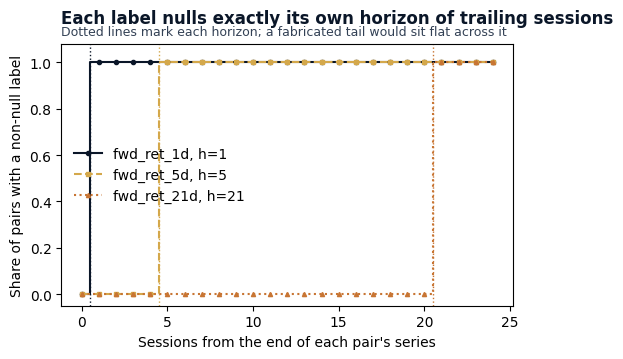

In [7]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)
palette = (COLORS["blue"], COLORS["amber"], COLORS["copper"])
markers = ("o-", "s--", "^:")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour, fmt in zip(LABEL_NAMES, palette, markers, strict=True):
    tag = f"{name}, h={HORIZONS[name]}"
    ax.plot(profile["from_end"], profile[name], fmt, ds="steps-mid", ms=3, c=colour, label=tag)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Sessions from the end of each pair's series")
ax.set_ylabel("Share of pairs with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label nulls exactly its own horizon of trailing sessions",
    subtitle="Dotted lines mark each horizon; a fabricated tail would sit flat across it",
)
ax.legend(loc="center left", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each pair's series.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing in every regime? Everything from
here through Section G is computed on the development window only, sealed on the label's
**endpoint** rather than its observation date: a row observed shortly before the holdout
still resolves inside it, so a filter on the observation date looks sealed and is not. The
label files keep every row, because the seal governs what this notebook looks at rather
than what it writes.

In [8]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_1d: 67,080 development rows through 2023-12-28
fwd_ret_5d: 67,000 development rows through 2023-12-21
fwd_ret_21d: 66,680 development rows through 2023-11-29


All three labels go on one axis with identical bins and a logarithmic count axis. The claim
the figure has to support is about shape rather than width, which three dispersion scalars
would carry: each longer horizon spreads the same centred body wider. The axis is narrower
than every label's range, so rows outside it are counted below rather than drawn, and the
figure is therefore evidence about the body and not about the tails. The skew printed
beneath it is the quantity that does read the tails, and for the one-session label the two
disagree: a handful of sessions of sharp depreciation sit outside the drawn range and pull
it well negative. That asymmetry is a property of a daily FX label, and a plot of its
central mass cannot show it.

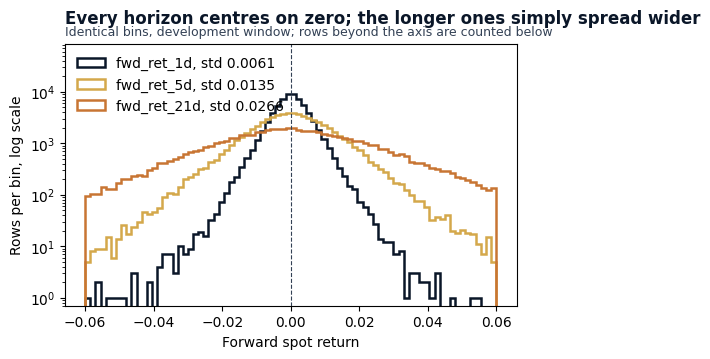

fwd_ret_1d: std 0.00610, skew -0.762, share positive 0.503, 9 left and 5 right of the axis
fwd_ret_5d: std 0.01348, skew -0.173, share positive 0.503, 87 left and 82 right of the axis
fwd_ret_21d: std 0.02664, skew +0.021, share positive 0.504, 1,047 left and 1,375 right of the axis
width ratio 4.37 against 4.58 under square-root-of-horizon scaling


In [9]:
bins = np.linspace(-0.06, 0.06, 81)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(LABEL_NAMES, palette, strict=True):
    series = dev[name][name]
    tag = f"{name}, std {series.std():.4f}"
    ax.hist(series.to_numpy(), bins=bins, histtype="step", lw=1.8, color=colour, label=tag)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward spot return")
ax.set_ylabel("Rows per bin, log scale")
ax.set_ylim(0.7, ax.get_ylim()[1] * 6)  # headroom so the legend clears the tallest bin
add_message_title(
    ax,
    "Every horizon centres on zero; the longer ones simply spread wider",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Histograms of the three labels on identical bins and a log count axis.")

std = {name: dev[name][name].std() for name in LABEL_NAMES}
for name in LABEL_NAMES:
    frame, column = dev[name], pl.col(name)
    out = frame.filter(column < bins[0]).height, frame.filter(column > bins[-1]).height
    print(
        f"{name}: std {std[name]:.5f}, skew {frame[name].skew():+.3f}, share positive "
        f"{(frame[name] > 0).mean():.3f}, {out[0]:,} left and {out[1]:,} right of the axis"
    )
ratio = std[LONGEST_LABEL] / std[PRIMARY_LABEL]
root_h = math.sqrt(HORIZONS[LONGEST_LABEL] / PRIMARY_HORIZON)
print(f"width ratio {ratio:.2f} against {root_h:.2f} under square-root-of-horizon scaling")

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label
ranked across a cross-section, the quantity that has to be stable is the spread the model
ranks within: where it is not, the same rank correlation buys a different amount of return.
The spread is taken across pairs on each session first and only then averaged over the
year. Pooling every pair-session in a year into one standard deviation instead measures
something else: it adds the movement of the panel's own mean from session to session to the
spread across pairs on a session, and a ranking model is scored on the second alone.

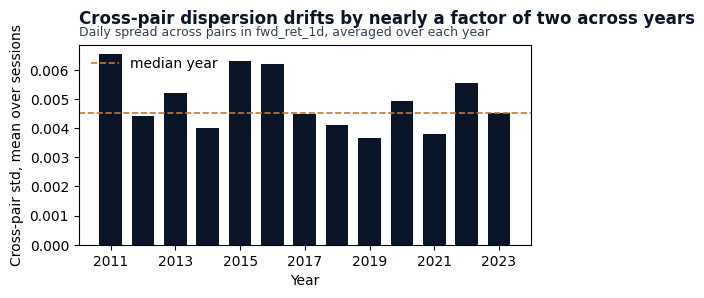

dispersion peaks at 0.65% in 2011 against 0.36% in 2019, a ratio of 1.79; median year 0.45%


In [10]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean())
    .sort("year")
)
peak, low = (annual.sort("dispersion", descending=d).row(0, named=True) for d in (True, False))
median_dispersion = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_dispersion, color=COLORS["copper"], linestyle="--", lw=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::2])
ax.set_xlabel("Year")
ax.set_ylabel("Cross-pair std, mean over sessions")
add_message_title(
    ax,
    "Cross-pair dispersion drifts by nearly a factor of two across years",
    subtitle=f"Daily spread across pairs in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-pair dispersion of the primary label.")

print(
    f"dispersion peaks at {peak['dispersion']:.2%} in {peak['year']:.0f} against "
    f"{low['dispersion']:.2%} in {low['year']:.0f}, a ratio of "
    f"{peak['dispersion'] / low['dispersion']:.2f}; median year {median_dispersion:.2%}"
)

On the development window the one-session label has a standard deviation of 0.00610 and
the monthly label 0.02664, a ratio of 4.37 against the 4.58 that square-root-of-horizon
scaling implies. All three are close to balanced around zero - the share of positive rows
runs 0.503 to 0.504 - so the task is not one of predicting a drift but of ranking small
deviations from it. The tails are not balanced at the daily horizon: skew runs -0.762 at
one session against -0.173 at five and +0.021 at twenty-one, so the one-session label
carries a left tail the longer two average away. The spread the ranking happens inside is
not constant either: cross-pair dispersion peaks at 0.65% in 2011 against 0.36% in 2019, a
ratio of 1.79.

## F. Overlap and effective sample size

Sampling a multi-session label at every session makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is priced
in. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per pair,
because concurrency is a property of one pair's own overlapping windows.

The one-session label is the case that checks the measurement rather than the data.
Consecutive one-session forward returns are built from disjoint return intervals, so no row
shares any part of its window with a neighbour, every uniqueness weight must be one, and
the effective count has to come back equal to the row count. A weighting that counted the
anchor session as consumed would halve it instead, and would read as a refinement.

Disjoint is not independent, and the figure is what says so: the one-session label shares
no part of its window with any other row, and its autocorrelation is small but not zero at
every lag drawn. Average uniqueness prices shared windows, not serial dependence.

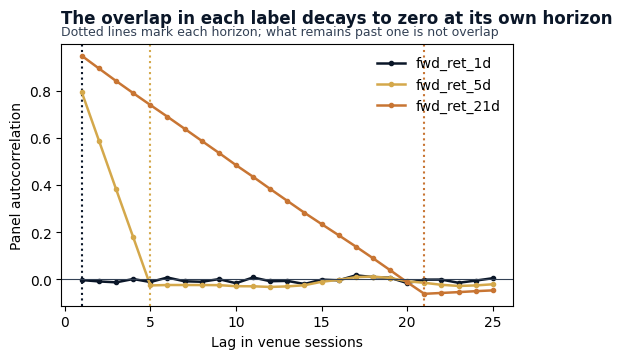

fwd_ret_1d: N=67,080, N_eff=67,080, ratio 1.0000 against 1.0000 for windows overlapping this fully; autocorrelation -0.003 at lag one, -0.003 at its horizon


fwd_ret_5d: N=67,000, N_eff=13,416, ratio 0.2002 against 0.2000 for windows overlapping this fully; autocorrelation +0.792 at lag one, -0.026 at its horizon
fwd_ret_21d: N=66,680, N_eff=3,194, ratio 0.0479 against 0.0476 for windows overlapping this fully; autocorrelation +0.947 at lag one, -0.061 at its horizon


In [11]:
max_lag = HORIZONS[LONGEST_LABEL] + 4
acf = {n: panel_autocorrelation(dev[n], n, max_lag=max_lag, bar_col="session") for n in LABEL_NAMES}
lags = np.arange(1, max_lag + 1)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(LABEL_NAMES, palette, strict=True):
    ax.plot(lags, acf[name], "o-", ms=3, c=colour, lw=1.8, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.5)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in venue sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "The overlap in each label decays to zero at its own horizon",
    subtitle="Dotted lines mark each horizon; what remains past one is not overlap",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of the three labels against lag in sessions.")

# A horizon-h label consumes the h returns realised over its window, and its neighbour one
# session later shares h-1 of them, so average uniqueness converges to 1/h.
for label_name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(dev[label_name], horizon=horizon, bar_col="session")
    print(
        f"{label_name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / horizon:.4f} for windows overlapping this fully; autocorrelation "
        f"{acf[label_name][0]:+.3f} at lag one, {acf[label_name][horizon - 1]:+.3f} at its horizon"
    )

The one-session label's 67,080 development rows carry 67,080 effective observations, the
answer that confirms the weighting rather than the data: consecutive windows are disjoint,
so every uniqueness weight is one. The weekly label's 67,000 rows carry 13,416, a ratio of
0.2002 against 0.2000, and the monthly label's 66,680 rows carry 3,194, a ratio of 0.0479
against 0.0476. Autocorrelation is -0.003 at lag one for the one-session label, +0.792 for
the weekly and +0.947 for the monthly, and each falls to zero at its own horizon. The purge
gap a fold needs is set by the forward window itself, not by these counts.

## G. Baseline floor

One signal against the primary label on the sealed development window, with no feature
engineering: the raw two-quarter return the reversal hypothesis names, which
`03_financial_features` recomputes as a momentum family. A reversal hypothesis predicts a
**negative** information coefficient, so the sign is part of the claim and not a detail.

The coefficient is the cross-sectional rank correlation on each session, averaged over
sessions, which is the quantity a ranking model is scored on; pooling every pair-session
instead mixes a cross-sectional claim with a time-series one. The library call returns its
series ordered by time, which the standard error depends on. The minimum cross-section is
half the median rather than a bare count, so it means the same thing on a universe of
another size. The primary label does not overlap, but its IC series is still serially
dependent, because the two-quarter return that produces it moves slowly, so the standard
error is HAC-adjusted and the Newey-West rule sets the bandwidth.

In [12]:
LOOKBACK = 126  # two quarters, the reversal window the hypothesis names

baseline = (
    labels_df.with_columns(
        (pl.col("close") / pl.col("close").shift(LOOKBACK).over("symbol") - 1).alias("ret_126d")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls([PRIMARY_LABEL, "ret_126d"])
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="ret_126d",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: {LOOKBACK}-session return against {PRIMARY_LABEL}, {baseline.height:,} rows, "
    f"minimum cross-section {min_obs} pairs"
)
print(f"  sessions scored {ic.height:,}, mean IC {stats['mean_ic']:+.4f}")
print(
    f"  HAC t {stats['t_stat']:+.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:+.2f}, p {stats['p_value']:.3g}"
)

Baseline: 126-session return against fwd_ret_1d, 64,560 rows, minimum cross-section 10 pairs
  sessions scored 3,228, mean IC +0.0035
  HAC t +0.46 on 8 Bartlett lags, naive t +0.43, p 0.649


The two-quarter return earns a mean information coefficient of +0.0035 against the
one-session label over 3,228 scored sessions on a cross-section of at least 10 pairs. The
reversal hypothesis predicts a negative coefficient; this one is positive, and neither the
naive t-statistic of +0.43 nor the HAC statistic of +0.46 on 8 Bartlett lags separates it
from zero, at a p-value of 0.649. The floor a feature has to clear at the daily horizon is
therefore zero, and the reversal premise is not visible in the raw signal at this cadence.

## H. Artifacts and the audit record

Each label is written with a digest sidecar beside it, recording the content digest of the
values written, the row count, the key columns, the notebook that wrote it and the digest
of the price data it was built from. That last field is what ties a label to its data
vintage.

The folds that train models are fixed boundaries in `config/cv_config.json`, which
`06_linear`, `07_gbm` and `09_dl_tcn` each read directly, and which follow the walk-forward
shape `config/setup.yaml` declares. They are not derived from the timeline of the label
parquet written here, so a label whose coverage changes does not move a fold with it, and
the two have to be checked against each other rather than assumed consistent.

In [13]:
for label_name in LABEL_NAMES:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_1d.parquet: 77,460 rows, digest 38a71b059d90d7f6
fwd_ret_5d.parquet: 77,380 rows, digest f626c04c286f525a
fwd_ret_21d.parquet: 77,060 rows, digest 8ea4f735324607a6


The record Chapter 7.2 requires to close a label definition, one row per label, built from
the values computed above rather than written by hand.

In [14]:
readers = dict.fromkeys(LABEL_NAMES, "the model stages, as a variant declared in `setup.yaml`")
readers[PRIMARY_LABEL] = "03_financial_features.py, as the label it names directly"
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       New York 5pm close of the venue session at t"
        f"\n  horizon      {horizon} venue sessions"
        f"\n  resolution   fixed at t+h; the session close is the tie-break the calendar sets"
        f"\n  overlap      {horizon - 1} sessions shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():+.6f}, std {frame[label_name].std():.5f}"
        f"\n  consumed by  {readers[label_name]}"
    )


Label audit record

fwd_ret_1d
  anchor       New York 5pm close of the venue session at t
  horizon      1 venue sessions
  resolution   fixed at t+h; the session close is the tie-break the calendar sets
  overlap      0 sessions shared by consecutive rows
  base rate    mean +0.000042, std 0.00610
  consumed by  03_financial_features.py, as the label it names directly

fwd_ret_5d
  anchor       New York 5pm close of the venue session at t
  horizon      5 venue sessions
  resolution   fixed at t+h; the session close is the tie-break the calendar sets
  overlap      4 sessions shared by consecutive rows
  base rate    mean +0.000211, std 0.01348
  consumed by  the model stages, as a variant declared in `setup.yaml`

fwd_ret_21d
  anchor       New York 5pm close of the venue session at t
  horizon      21 venue sessions
  resolution   fixed at t+h; the session close is the tie-break the calendar sets
  overlap      20 sessions shared by consecutive rows
  base rate    mean +0.000829, 

## Key takeaways

1. **Put the bars on the session clock the cadence is defined in before measuring
   anything.** Spot FX has no exchange close, so the daily bar is a convention; aggregating
   on the UTC date instead of the venue session moves a third of every day into the wrong
   row, and every shift after that inherits the error.
2. **Assert the window, do not describe it.** An incomplete window, a window spanning a
   hole in a pair's quoting history and a label crossing a pair boundary all fail without
   raising and leave plausible numbers behind.
3. **Seal a diagnostic on the label's endpoint.** A row observed before the holdout whose
   outcome resolves inside it is a holdout row, so the usable boundary is the boundary
   minus the horizon, counted on each pair's own sessions.
4. **Check an effective-sample measurement at a horizon whose answer is known by
   inspection.** Consecutive one-session returns are disjoint, so the effective count has
   to come back equal to the row count; a weighting that counts the anchor session halves
   it instead, which reads as a refinement rather than a bug.
5. **State the sign the hypothesis predicts before measuring the floor.** Reversal predicts
   a negative information coefficient, so a positive one of the same magnitude is evidence
   against the premise rather than a weak version of it.

**Known limitations.** Close-to-close is not the next-bar-open execution the backtest fills
at, and nothing here measures that gap. The universe is a fixed twenty-pair list rather
than a liquidity screen applied point in time. The baseline is one signal at one lookback
against one horizon, and `05_evaluation` is where the same signal is scored against all
three.

**Next**: `03_financial_features.py` builds the momentum, carry and volatility features and
evaluates them against these labels.